# 04 Clustering Analysis

This notebook applies unsupervised learning to identify groups of similar user-anime interactions. Unlike regression and classification, clustering does not use the `score` target as a label to predict; instead, it searches for structure in the feature representation itself.

The analysis combines K-Means clustering, hierarchical agglomerative clustering, optimal K selection, and dendrogram interpretation. The goal is to understand whether the MyAnimeList interactions contain natural behavioural segments, such as groups with similar watch status, episode progress, or rating-related patterns.


In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(os.path.abspath('..'))

RANDOM_STATE = 42
SAMPLE_SIZE = 50000
RATING_DTYPES = {
    'username': 'category',
    'anime_id': 'int32',
    'status': 'category',
    'score': 'float32',
    'is_rewatching': 'float32',
    'num_watched_episodes': 'float32',
}

%matplotlib inline
sns.set_theme(style='whitegrid')


In [2]:
from src.clustering import optimal_k_elbow, plot_dendrogram, run_hierarchical, run_kmeans
from src.pca_svd import apply_pca
from src.preprocessing import build_preprocess


## Data Preparation with SVD-Reduced Feature Space

Clustering is applied to the SVD-reduced feature space rather than the raw encoded features. This is important because the preprocessing pipeline produces a high-dimensional matrix after one-hot encoding categorical variables. In high-dimensional sparse spaces, distance measures can become less informative, and clustering algorithms may be dominated by rare categorical indicators rather than broad behavioural patterns.

SVD projects the data into a smaller set of continuous latent components that preserve most of the overall variation. This makes Euclidean distances more stable for K-Means and makes hierarchical clustering computationally more feasible. The sample limit is also necessary because hierarchical clustering has high computational and memory cost when the number of observations is large.


In [3]:
df = pd.read_csv('../datasets/ratings.csv', dtype=RATING_DTYPES)
df = df[df['score'] > 0]
df = df[df['num_watched_episodes'] <= 10000]
df = df[df['num_watched_episodes'] >= 0]
df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)

TARGET = 'score'
preprocess = build_preprocess(df, TARGET)
X = preprocess.fit_transform(df.drop(columns=[TARGET]))
X_reduced, svd = apply_pca(X, variance=0.95)

cluster_input = X_reduced[:10000]
print('Cluster matrix shape:', cluster_input.shape)


Cluster matrix shape: (10000, 2)


## Optimal Number of Clusters: Elbow and Silhouette

The optimal number of clusters is evaluated using both inertia and silhouette score. Inertia is the within-cluster sum of squared distances to cluster centroids. Lower inertia means observations are closer to their assigned centroids, but inertia always decreases as K increases, so it cannot be used alone. The elbow method looks for a point where adding more clusters produces diminishing returns.

Silhouette score measures how well each observation fits within its assigned cluster compared with the nearest alternative cluster. Values closer to 1 indicate well-separated clusters, values near 0 indicate overlapping clusters, and negative values suggest possible misassignment. Unlike inertia, silhouette explicitly considers separation between clusters.

Using both metrics provides a more balanced decision. The selected K should have reasonably low inertia while also producing good separation. In the context of anime user behaviour, the chosen K represents the number of broad behavioural segments detected in the reduced feature space, not necessarily objective genre groups or quality categories.


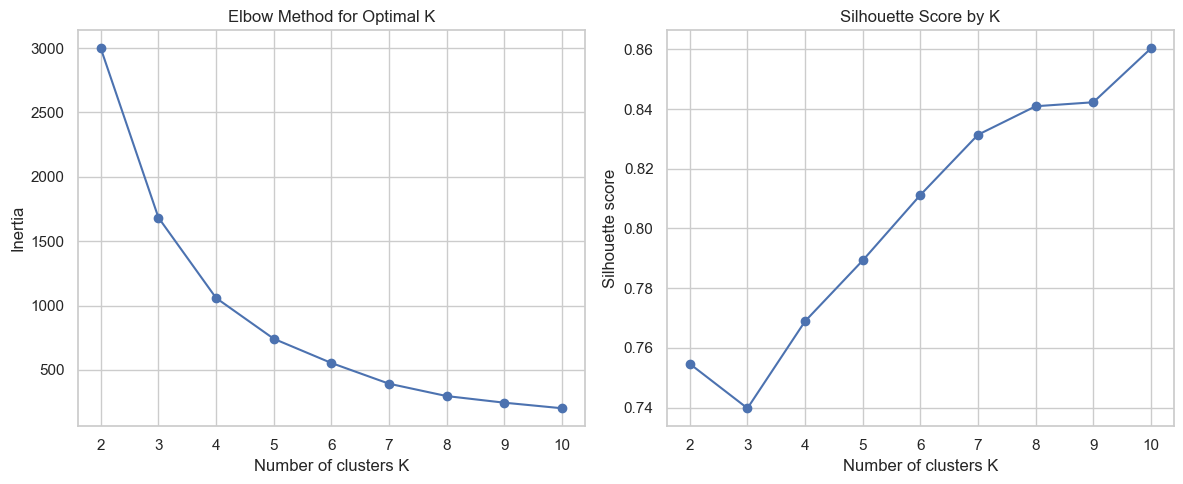

,k,inertia,silhouette
0,2,2997.985699,0.754638
1,3,1683.030862,0.739749
2,4,1058.587487,0.768913
3,5,741.779875,0.789272
4,6,553.501124,0.811206
5,7,392.457354,0.831388
6,8,296.451378,0.840930
7,9,244.979438,0.842265
8,10,201.715657,0.860309


Selected number of clusters: 10


In [4]:
cluster_results, best_k = optimal_k_elbow(cluster_input, max_k=10)
display(cluster_results)
print('Selected number of clusters:', best_k)


## K-Means Clustering

K-Means partitions the reduced feature space into K groups by iteratively assigning observations to the nearest centroid and updating the centroid positions. It assumes clusters are roughly compact and spherical in the transformed space. This assumption is not always true for behavioural data, but K-Means is efficient and provides a useful baseline for segmentation.

The displayed cluster counts show the size of each discovered group. Balanced counts suggest that the model found broad groups of comparable frequency, while highly uneven counts may indicate one dominant behavioural pattern and several smaller specialised segments. The inertia value summarises compactness, but it should be interpreted together with the earlier silhouette analysis rather than as an absolute quality measure.


In [5]:
labels_km, inertia = run_kmeans(cluster_input, n_clusters=best_k)
print('K-Means inertia:', inertia)
display(pd.Series(labels_km, name='kmeans_cluster').value_counts().sort_index().to_frame('count'))


K-Means inertia: 201.7156574473972


,count
kmeans_cluster,
0,4888
1,1969
2,1542
3,170
4,223
5,288
6,151
7,155
8,360


In [6]:
cluster_profile = pd.DataFrame(cluster_input)
cluster_profile['cluster'] = labels_km
display(cluster_profile.groupby('cluster').mean().round(3))
print('Cluster sizes:')
display(pd.Series(labels_km).value_counts().sort_index())


,0,1
cluster,,
0,0.691,0.784
1,-0.963,1.539
2,1.282,0.514
3,3.114,-0.413
4,-0.680,0.311
5,0.012,1.094
6,0.226,-0.103
7,-1.674,0.765
8,-0.529,1.341


Cluster sizes:


0    4888
1    1969
2    1542
3     170
4     223
5     288
6     151
7     155
8     360
9     254
Name: count, dtype: int64

## Hierarchical Clustering and Dendrogram

Agglomerative clustering starts with each observation as its own cluster and progressively merges the closest groups. Ward linkage is used because it attempts to minimise the increase in within-cluster variance at each merge, making it conceptually related to the compactness objective used by K-Means.

The hierarchical cluster counts can be compared with the K-Means counts to identify where the two methods agree or disagree. Agreement suggests stable structure in the feature space. Disagreement may occur because K-Means optimises centroids globally, while agglomerative clustering builds a merge hierarchy and cannot undo earlier merge decisions.

The dendrogram visualises the hierarchy of merges. Short merge distances indicate groups that are very similar, while long vertical jumps indicate clusters that remain distinct until late in the merging process. Large jumps near the top of the dendrogram support the existence of separated high-level groups. Because the dendrogram uses a sample and may be truncated for readability, it should be interpreted as structural evidence rather than a complete representation of all observations.


,count
hierarchical_cluster,
0,341
1,138
2,155
3,208
4,4890
5,393
6,1501
7,1969
8,150


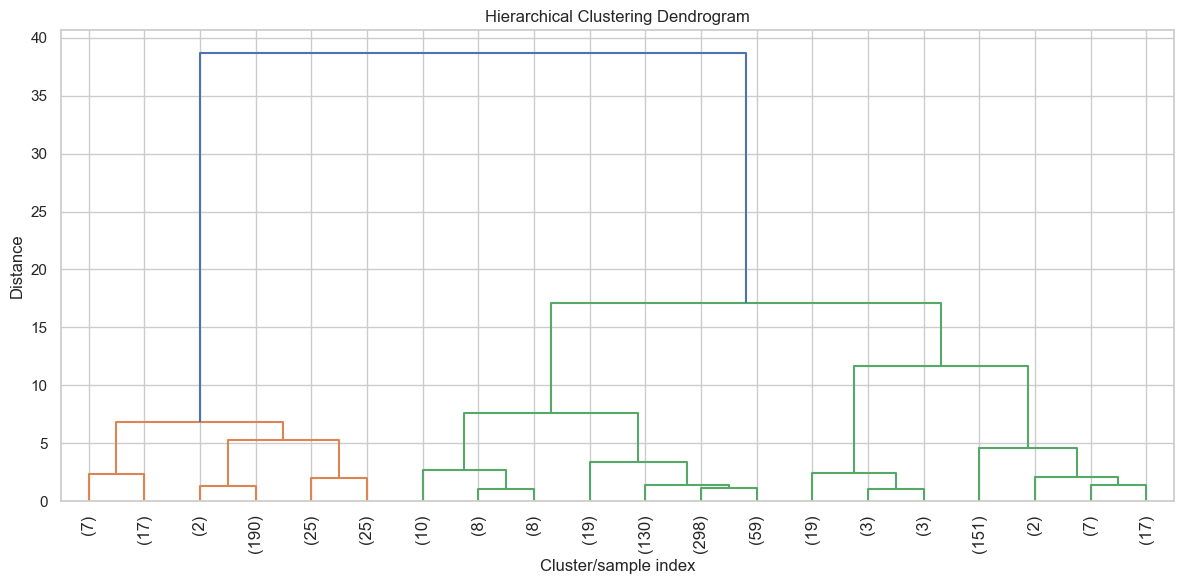

In [7]:
labels_hc = run_hierarchical(cluster_input, n_clusters=best_k, linkage_method='ward')
display(pd.Series(labels_hc, name='hierarchical_cluster').value_counts().sort_index().to_frame('count'))
plot_dendrogram(cluster_input, method='ward', sample_size=1000)


## Critical Interpretation and Limitations

The selected number of clusters should be interpreted as a practical segmentation of interaction behaviour rather than a definitive taxonomy of anime users. Clusters may reflect combinations of watch status, episode progress, and encoded categorical variables, but SVD components are latent and not directly named. Additional profiling would be required to describe each cluster in substantive terms, for example by comparing original feature averages or rating distributions within each group.

K-Means and hierarchical clustering can reveal complementary views. If both methods produce similar cluster sizes and stable groupings, the segmentation is more credible. If they disagree, this may indicate overlapping clusters, non-spherical shapes, or sensitivity to distance metrics. Behavioural data from MyAnimeList is likely noisy and heterogeneous, so perfect separation is not expected.

The main limitations are dimensionality reduction, sampling, and distance assumptions. SVD may remove low-variance but behaviourally meaningful information, the sample may not represent rare user patterns, and Euclidean distance may not capture all relevant similarity in mixed categorical-numeric data. Therefore, clustering results should be used as exploratory insight rather than as labelled ground truth.


In [8]:
from pathlib import Path
Path('../artifacts').mkdir(exist_ok=True)
cluster_results.to_csv('../artifacts/cluster_results.csv', index=False)


In [9]:
# Export dashboard artifacts from Notebook 04
from pathlib import Path

ARTIFACTS_DIR = Path('../artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

cluster_results_export, best_k_export = optimal_k_elbow(
    cluster_input,
    max_k=10,
    output_path=ARTIFACTS_DIR / 'elbow_kmeans.png',
)
cluster_results_export.to_csv(ARTIFACTS_DIR / 'cluster_results.csv', index=False)
plot_dendrogram(
    cluster_input,
    method='ward',
    sample_size=1000,
    output_path=ARTIFACTS_DIR / 'dendrogram.png',
)

print('Notebook 04 exported dashboard artifacts:')
print('- cluster_results.csv')
print('- elbow_kmeans.png')
print('- dendrogram.png')
print('Selected K:', best_k_export)


Notebook 04 exported dashboard artifacts:
- cluster_results.csv
- elbow_kmeans.png
- dendrogram.png
Selected K: 10
